# Support Data Ticket Predication Model

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [3]:
# Load the dataset
df = pd.read_csv('supportTicketData.csv')

# Understanding the dataset

In [4]:
df.head()

,TicketID,Ticket detailed description,urgency-Priority
0,123456,connection issues with assigned address hi fac...,P1
1,123457,cannot access hi cannot access fallowing link ...,P2
2,123458,re address shown valid dear colleagues remarke...,P1
3,123459,sent tuesday critical alert following alert oc...,P2
4,123460,code spelling mistake hello should discover fo...,P2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19796 entries, 0 to 19795
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   TicketID                     19796 non-null  int64 
 1   Ticket detailed description  19796 non-null  object
 2   urgency-Priority             19796 non-null  object
dtypes: int64(1), object(2)
memory usage: 464.1+ KB


In [6]:
print(df['urgency-Priority'].unique())  # check unique target values


['P1' 'P2' 'P3']


# Exploratory Data Analysis

<Axes: xlabel='urgency-Priority'>

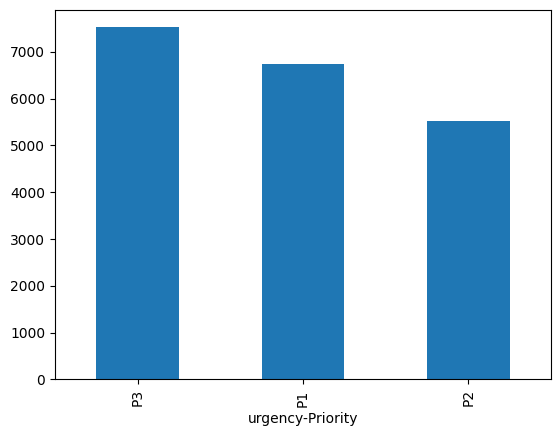

In [7]:
# Distribution of target variable
df['urgency-Priority'].value_counts().plot(kind='bar')


# Text length Analysis

In [8]:
df['ticket_length'] = df['Ticket detailed description'].apply(len)
print(df['ticket_length'].describe())

count    19796.000000
mean       293.695848
std        414.341088
min          2.000000
25%        100.000000
50%        171.000000
75%        302.000000
max       7011.000000
Name: ticket_length, dtype: float64


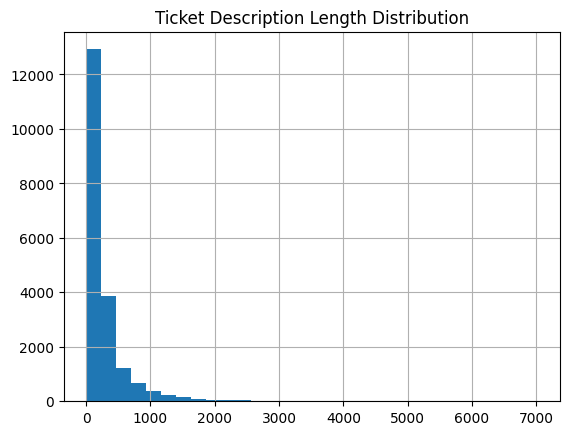

In [9]:
# Histogram for ticket detail description
df['ticket_length'].hist(bins = 30)
plt.title("Ticket Description Length Distribution")
plt.show()

In [10]:
# Word Count Analysis
df['word_count'] = df['Ticket detailed description'].apply(lambda x: len(str(x).split()))

In [11]:
print(df['word_count'].describe())


count    19796.000000
mean        44.707113
std         61.813498
min          1.000000
25%         15.000000
50%         26.000000
75%         46.000000
max        979.000000
Name: word_count, dtype: float64


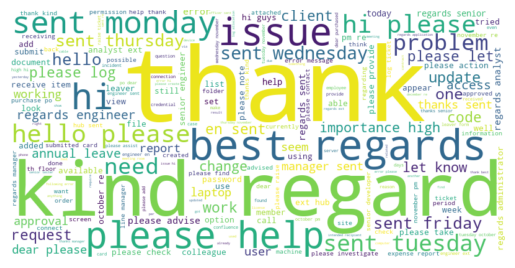

In [12]:
# Frequent word visualization
from wordcloud import WordCloud

text_data = ' '.join(df['Ticket detailed description'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


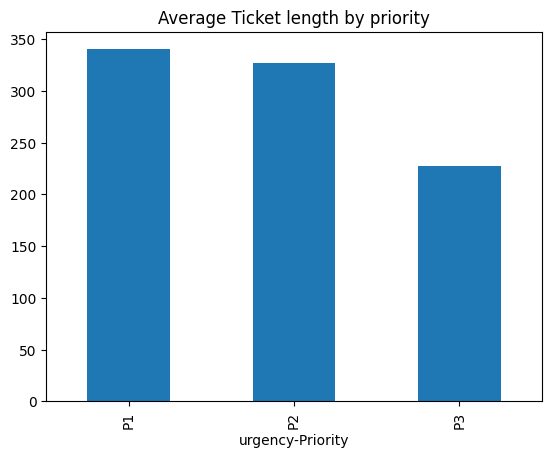

In [13]:
# Priority wise Analysis
df.groupby('urgency-Priority')['ticket_length'].mean().plot(kind = 'bar')
plt.title('Average Ticket length by priority')
plt.show()

In [14]:
# Duplicate ticket analysis
print("Duplicate descriptions:", df['Ticket detailed description'].duplicated().sum())


Duplicate descriptions: 0


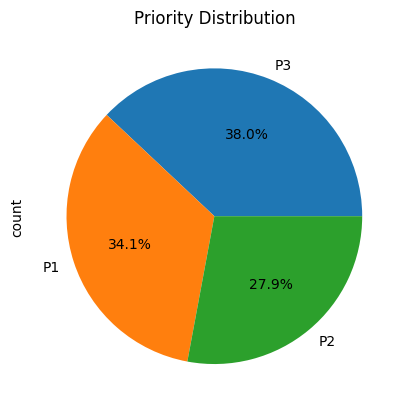

In [15]:
# Checking the class implance
df['urgency-Priority'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Priority Distribution')
plt.show()


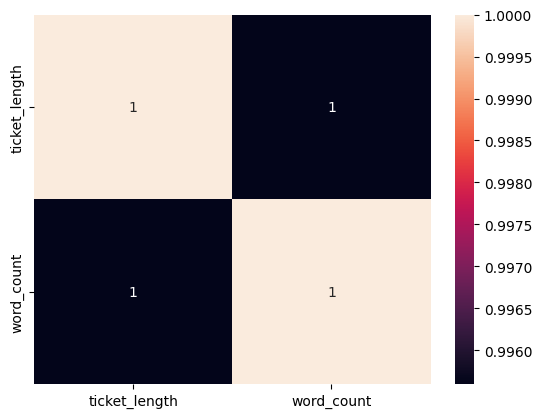

In [16]:
# correlation Heatmap
numeric_cols = ['ticket_length', 'word_count']
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.show()


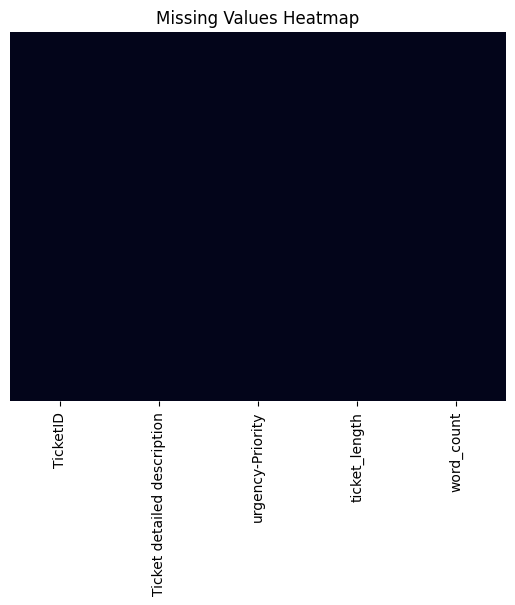

In [17]:
# Missing Data Visualization
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()


In [18]:
# N gram Analysis
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
ngrams = vectorizer.fit_transform(df['Ticket detailed description'])
sum_words = ngrams.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
print(words_freq[:10])  # Top 10 bigrams


[('kind regards', np.int64(4483)), ('best regards', np.int64(3380)), ('sent monday', np.int64(2349)), ('sent tuesday', np.int64(2238)), ('sent wednesday', np.int64(2038)), ('sent thursday', np.int64(1879)), ('sent friday', np.int64(1780)), ('did leaver', np.int64(1465)), ('let know', np.int64(1274)), ('importance high', np.int64(1190))]


In [19]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


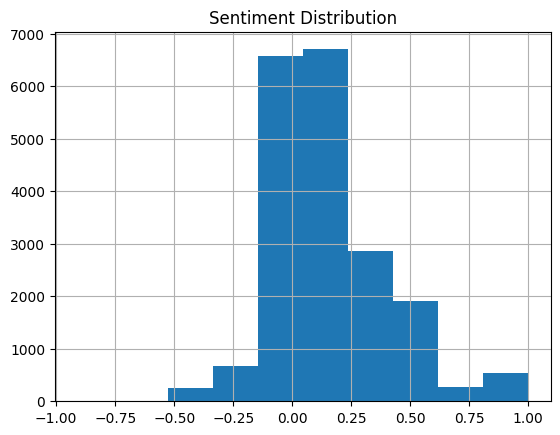

In [20]:
from textblob import TextBlob

df['sentiment'] = df['Ticket detailed description'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['sentiment'].hist()
plt.title('Sentiment Distribution')
plt.show()


In [21]:
import re

def clean_text(text):
    if pd.isnull(text):
        return ""  # Handle NaN values gracefully
    
    text = str(text)  # Ensure it's a string
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # Remove special characters (keep alphanumeric)
    text = re.sub(r'\d+', '', text)  # Remove numbers (optional, depending on your use case)
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces and trim
    
    return text

# Apply to DataFrame
df['Cleaned_Ticket detailed description'] = df['Ticket detailed description'].apply(clean_text)

# Verify cleaned data
print(df[['Ticket detailed description', 'Cleaned_Ticket detailed description']].head())


                         Ticket detailed description  \
0  connection issues with assigned address hi fac...   
1  cannot access hi cannot access fallowing link ...   
2  re address shown valid dear colleagues remarke...   
3  sent tuesday critical alert following alert oc...   
4  code spelling mistake hello should discover fo...   

                 Cleaned_Ticket detailed description  
0  connection issues with assigned address hi fac...  
1  cannot access hi cannot access fallowing link ...  
2  re address shown valid dear colleagues remarke...  
3  sent tuesday critical alert following alert oc...  
4  code spelling mistake hello should discover fo...  


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the cleaned text column
cleaned_column = 'Cleaned_Ticket detailed description'

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features if needed

# Apply vectorizer
tfidf_matrix = vectorizer.fit_transform(df[cleaned_column])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (19796, 5000)


In [23]:
print(df.dtypes)


TicketID                                 int64
Ticket detailed description             object
urgency-Priority                        object
ticket_length                            int64
word_count                               int64
sentiment                              float64
Cleaned_Ticket detailed description     object
dtype: object


In [24]:
# Applying the tokenization
from nltk.tokenize import word_tokenize

# Function to tokenize text
def tokenize_text(text):
    return word_tokenize(str(text))

# Apply to your DataFrame column
df['tokenized_description'] = df['Ticket detailed description'].apply(tokenize_text)

# View results
print(df[['Ticket detailed description', 'tokenized_description']].head())


                         Ticket detailed description  \
0  connection issues with assigned address hi fac...   
1  cannot access hi cannot access fallowing link ...   
2  re address shown valid dear colleagues remarke...   
3  sent tuesday critical alert following alert oc...   
4  code spelling mistake hello should discover fo...   

                               tokenized_description  
0  [connection, issues, with, assigned, address, ...  
1  [can, not, access, hi, can, not, access, fallo...  
2  [re, address, shown, valid, dear, colleagues, ...  
3  [sent, tuesday, critical, alert, following, al...  
4  [code, spelling, mistake, hello, should, disco...  


In [25]:
#Lowercase and remove punctuation
import string

def clean_and_tokenize(text):
    text = str(text).lower()  # lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    return tokens

df['cleaned_tokens'] = df['Ticket detailed description'].apply(clean_and_tokenize)

print(df[['Ticket detailed description', 'cleaned_tokens']].head())


                         Ticket detailed description  \
0  connection issues with assigned address hi fac...   
1  cannot access hi cannot access fallowing link ...   
2  re address shown valid dear colleagues remarke...   
3  sent tuesday critical alert following alert oc...   
4  code spelling mistake hello should discover fo...   

                                      cleaned_tokens  
0  [connection, issues, with, assigned, address, ...  
1  [can, not, access, hi, can, not, access, fallo...  
2  [re, address, shown, valid, dear, colleagues, ...  
3  [sent, tuesday, critical, alert, following, al...  
4  [code, spelling, mistake, hello, should, disco...  


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['urgency_numeric'] = le.fit_transform(df['urgency-Priority'])


In [27]:
print(df.head())

   TicketID                        Ticket detailed description  \
0    123456  connection issues with assigned address hi fac...   
1    123457  cannot access hi cannot access fallowing link ...   
2    123458  re address shown valid dear colleagues remarke...   
3    123459  sent tuesday critical alert following alert oc...   
4    123460  code spelling mistake hello should discover fo...   

  urgency-Priority  ticket_length  word_count  sentiment  \
0               P1            248          39   0.000000   
1               P2            102          17   0.100000   
2               P1           1017         151   0.241667   
3               P2            290          40   0.066667   
4               P2             86          14   0.200000   

                 Cleaned_Ticket detailed description  \
0  connection issues with assigned address hi fac...   
1  cannot access hi cannot access fallowing link ...   
2  re address shown valid dear colleagues remarke...   
3  sent tuesday cr

# Feature Engineering

In [28]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Convert text into numerical representations using TF-IDF
# Assuming 'Cleaned_Ticket detailed description' is your cleaned text column
tfidf = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
X = tfidf.fit_transform(df['Cleaned_Ticket detailed description']).toarray()

# Save the vectorizer for deployment
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Step 2: Encode the target variable
# Mapping priorities (e.g., P1, P2, etc.) to numerical codes
priority_mapping = {'P1': 0, 'P2': 1, 'P3': 2}  # Map priorities to numbers

# Fix column name references
df['urgency-Priority_Code'] = df['urgency-Priority'].map(priority_mapping)

# Extract the target variable
y = df['urgency-Priority_Code']


# Split Data For Training and Testing 

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training Data: {X_train.shape}, Testing Data: {X_test.shape}')


Training Data: (15836, 5000), Testing Data: (3960, 5000)


# Train the Model

In [30]:
# Use a Random Forest Classifier for simplicity
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save the trained model
with open('ticket_priority_model.pkl', 'wb') as f:
    pickle.dump(model, f)


In [31]:
# Make predictions
y_pred = model.predict(X_test)

# Now safely print unique classes
print("Unique classes in y_test:", set(y_test))
print("Unique classes in y_pred:", set(y_pred))


Unique classes in y_test: {0, 1, 2}
Unique classes in y_pred: {np.int64(0), np.int64(1), np.int64(2)}


In [32]:
from sklearn.metrics import classification_report

# Define the labels explicitly to include all expected classes
labels = [0, 1, 2, 3]  # Corresponding to priority_mapping values

# Generate the classification report
report = classification_report(
    y_test, y_pred, labels=labels, target_names=list(priority_mapping.keys()), zero_division=0
)

# Print the report
print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

          P1       0.63      0.82      0.71      1350
          P2       0.66      0.39      0.49      1097
          P3       0.98      1.00      0.99      1513

    accuracy                           0.77      3960
   macro avg       0.57      0.55      0.55      3960
weighted avg       0.77      0.77      0.76      3960



C:\Users\asus\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:2687: UserWarning: labels size, 4, does not match size of target_names, 3
  warnings.warn(


# Evaluate the Model

In [33]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the performance
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7714646464646465


# Deployment

In [34]:
import pickle
# Load the vectorizer and model

with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('ticket_priority_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Predict for new data
new_ticket = ["The application is down, unable to access!"]
new_ticket_cleaned = [clean_text(ticket) for ticket in new_ticket]
new_ticket_vectorized = tfidf.transform(new_ticket_cleaned).toarray()

predicted_priority = model.predict(new_ticket_vectorized)
print("Predicted Priority:", list(priority_mapping.keys())[predicted_priority[0]])


Predicted Priority: P1


In [35]:
import pickle

# Correctly load the pickle file
file_path = r"C:/Users/asus/Desktop/SupportTicket Model/ticket_priority_model.pkl"

try:
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
        print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading the model: {e}")


Model loaded successfully!
